In [8]:
##### Creates plots of agricultural capital stock and labor vs income percentiles 

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
from matplotlib.patches import Rectangle
from scipy.signal import savgol_filter

In [18]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import capital and labor data
capital = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD.tif")
labor = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/rescaled_jobs.tif")

capital_country_avg = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif")
labor_country_avg = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif")

# Import production data
production = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif")

# Import income percentile data
GDP_pc_percentiles_national = rio.open_rasterio(f"{cd}/Data/Clean/GDP_percentiles/GDP_pc_percentiles_reprojected.tif")
GDP_pc_percentiles_global = rio.open_rasterio(f"{cd}/Data/Clean/GDP_percentiles/global_GDP_pc_percentiles_reprojected.tif")

# Import country boundaries 
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/plots_by_income"

In [19]:
### Data prep

# align rasters to capital grid
target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

capital = capital.rio.reproject(target_crs)
labor = labor.rio.reproject(target_crs)
capital_country_avg = capital_country_avg.rio.reproject(target_crs)
labor_country_avg = labor_country_avg.rio.reproject(target_crs)

production = production.rio.reproject(target_crs)
GDP_pc_percentiles_national = GDP_pc_percentiles_national.rio.reproject(target_crs)
GDP_pc_percentiles_global = GDP_pc_percentiles_global.rio.reproject(target_crs)

country_boundaries = country_boundaries.to_crs(target_crs)

# Identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

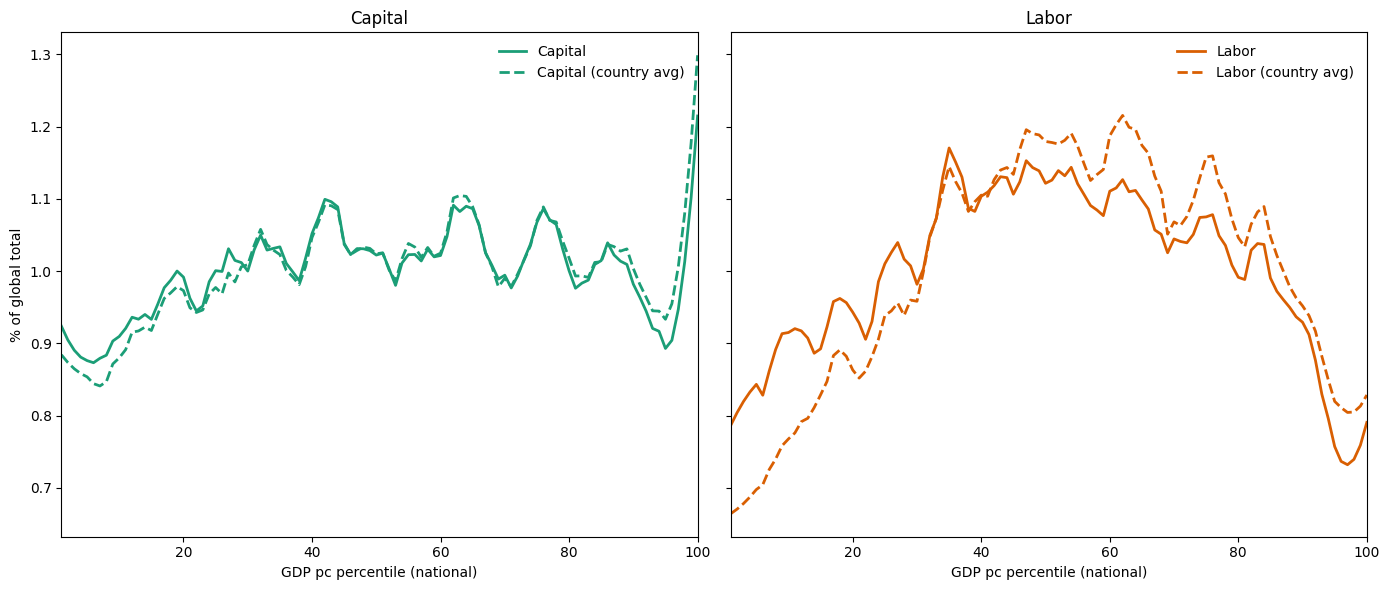

In [20]:
##### Plot capital and labor by income percentile (nationally defined)
# modelled by country average

### Align variable rasters to the percentile raster's grid
def match_grid(da, target):
    return da.rio.reproject_match(target, resampling=Resampling.nearest)

capital              = match_grid(capital, GDP_pc_percentiles_national)
labor                = match_grid(labor, GDP_pc_percentiles_national)
capital_country_avg  = match_grid(capital_country_avg, GDP_pc_percentiles_national)
labor_country_avg    = match_grid(labor_country_avg, GDP_pc_percentiles_national)


### Compute % of global total by income percentile
def pct_by_percentile(var_da, pctl_da):
    var  = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    # respect nodata flags if set on the raster
    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)

    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = ~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100)
    var_v  = var[valid]
    pctl_v = np.round(pctl[valid]).astype(int)

    total = np.nansum(var_v)

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v})
    grouped = df.groupby("percentile")["value"].sum()
    grouped = grouped.reindex(range(1, 101), fill_value=0)

    return (grouped / total) * 100  # % of global total per percentile bin

capital_pct     = pct_by_percentile(capital, GDP_pc_percentiles_national)
labor_pct       = pct_by_percentile(labor, GDP_pc_percentiles_national)
capital_avg_pct = pct_by_percentile(capital_country_avg, GDP_pc_percentiles_national)
labor_avg_pct   = pct_by_percentile(labor_country_avg, GDP_pc_percentiles_national)

def smooth(series, window=9, polyorder=2):
    """Savitzky-Golay smoothing. window must be odd and > polyorder."""
    smoothed = savgol_filter(series.values, window_length=window, polyorder=polyorder, mode="interp")
    return pd.Series(smoothed, index=series.index)

capital_pct_s     = smooth(capital_pct)
labor_pct_s       = smooth(labor_pct)
capital_avg_pct_s = smooth(capital_avg_pct)
labor_avg_pct_s   = smooth(labor_avg_pct)

### Plot: two panels side-by-side (Capital left, Labor right)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Panel 1: Capital (raw vs country avg)
ax = axes[0]
ax.plot(capital_pct_s.index, capital_pct_s.values, label="Capital",
         color="#1b9e77", linewidth=2)
ax.plot(capital_avg_pct_s.index, capital_avg_pct_s.values, label="Capital (country avg)",
         color="#1b9e77", linewidth=2, linestyle="--")
ax.set_xlabel("GDP pc percentile (national)")
ax.set_ylabel("% of global total")
ax.set_title("Capital")
ax.set_xlim(1, 100)
ax.legend(frameon=False)

# Panel 2: Labor (raw vs country avg)
ax = axes[1]
ax.plot(labor_pct_s.index, labor_pct_s.values, label="Labor",
         color="#d95f02", linewidth=2)
ax.plot(labor_avg_pct_s.index, labor_avg_pct_s.values, label="Labor (country avg)",
         color="#d95f02", linewidth=2, linestyle="--")
ax.set_xlabel("GDP pc percentile (national)")
ax.set_title("Labor")
ax.set_xlim(1, 100)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f"{fd}/capital_labor_by_national_percentile.png", dpi=300, bbox_inches="tight")
plt.show()

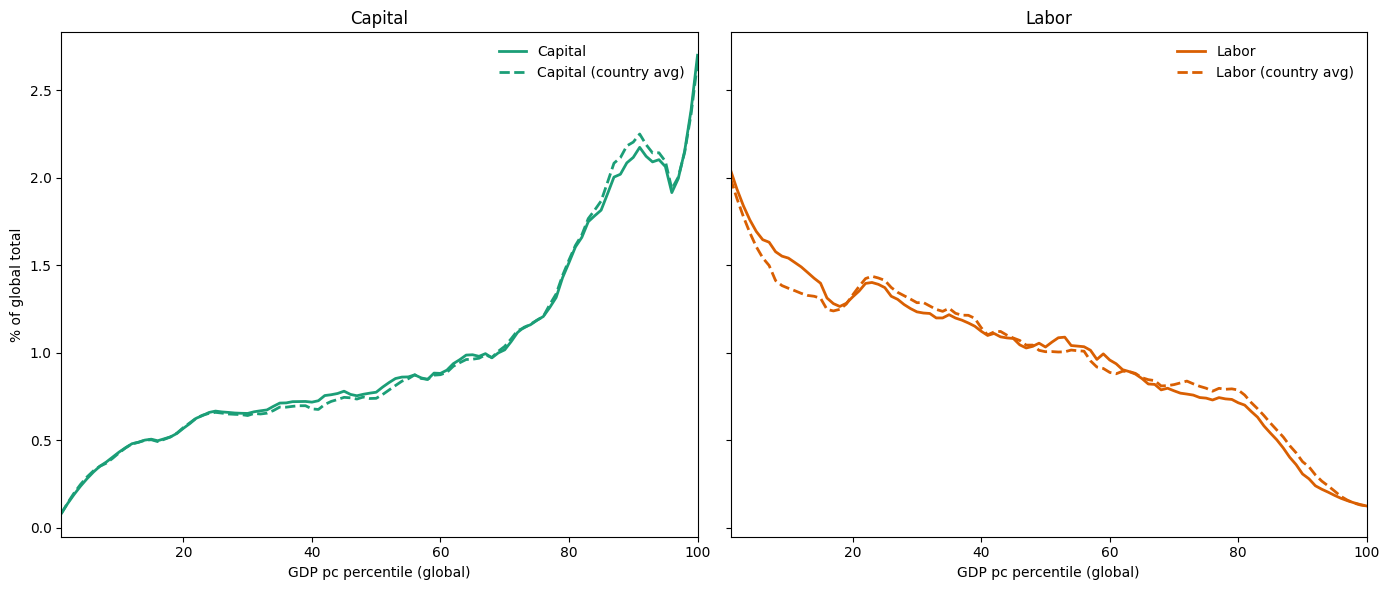

In [21]:
##### Plot capital and labor by income percentile (globally defined)
# modelled by country average

### Align variable rasters to the percentile raster's grid
def match_grid(da, target):
    return da.rio.reproject_match(target, resampling=Resampling.nearest)

capital              = match_grid(capital, GDP_pc_percentiles_global)
labor                = match_grid(labor, GDP_pc_percentiles_global)
capital_country_avg  = match_grid(capital_country_avg, GDP_pc_percentiles_global)
labor_country_avg    = match_grid(labor_country_avg, GDP_pc_percentiles_global)


### Compute % of global total by income percentile
def pct_by_percentile(var_da, pctl_da):
    var  = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    # respect nodata flags if set on the raster
    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)

    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = ~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100)
    var_v  = var[valid]
    pctl_v = np.round(pctl[valid]).astype(int)

    total = np.nansum(var_v)

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v})
    grouped = df.groupby("percentile")["value"].sum()
    grouped = grouped.reindex(range(1, 101), fill_value=0)

    return (grouped / total) * 100  # % of global total per percentile bin

capital_pct     = pct_by_percentile(capital, GDP_pc_percentiles_global)
labor_pct       = pct_by_percentile(labor, GDP_pc_percentiles_global)
capital_avg_pct = pct_by_percentile(capital_country_avg, GDP_pc_percentiles_global)
labor_avg_pct   = pct_by_percentile(labor_country_avg, GDP_pc_percentiles_global)

def smooth(series, window=9, polyorder=2):
    """Savitzky-Golay smoothing. window must be odd and > polyorder."""
    smoothed = savgol_filter(series.values, window_length=window, polyorder=polyorder, mode="interp")
    return pd.Series(smoothed, index=series.index)

capital_pct_s     = smooth(capital_pct)
labor_pct_s       = smooth(labor_pct)
capital_avg_pct_s = smooth(capital_avg_pct)
labor_avg_pct_s   = smooth(labor_avg_pct)

### Plot: two panels side-by-side (Capital left, Labor right)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Panel 1: Capital (raw vs country avg)
ax = axes[0]
ax.plot(capital_pct_s.index, capital_pct_s.values, label="Capital",
         color="#1b9e77", linewidth=2)
ax.plot(capital_avg_pct_s.index, capital_avg_pct_s.values, label="Capital (country avg)",
         color="#1b9e77", linewidth=2, linestyle="--")
ax.set_xlabel("GDP pc percentile (global)")
ax.set_ylabel("% of global total")
ax.set_title("Capital")
ax.set_xlim(1, 100)
ax.legend(frameon=False)

# Panel 2: Labor (raw vs country avg)
ax = axes[1]
ax.plot(labor_pct_s.index, labor_pct_s.values, label="Labor",
         color="#d95f02", linewidth=2)
ax.plot(labor_avg_pct_s.index, labor_avg_pct_s.values, label="Labor (country avg)",
         color="#d95f02", linewidth=2, linestyle="--")
ax.set_xlabel("GDP pc percentile (global)")
ax.set_title("Labor")
ax.set_xlim(1, 100)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f"{fd}/capital_labor_by_global_percentile.png", dpi=300, bbox_inches="tight")
plt.show()

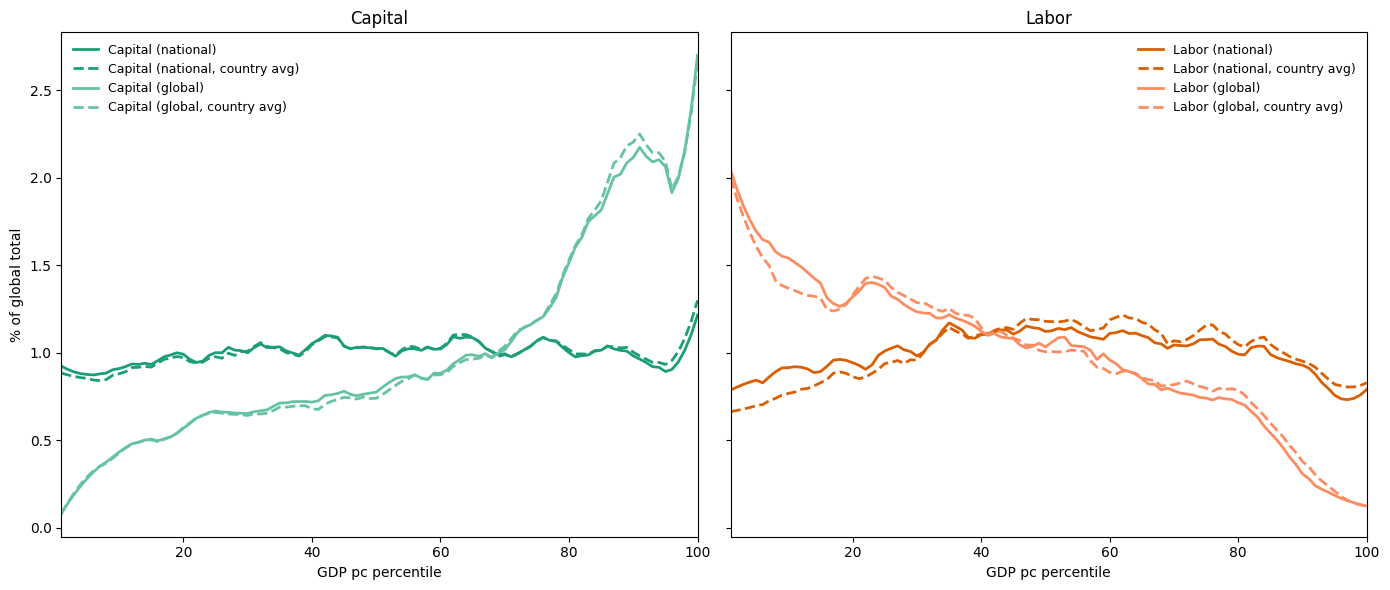

In [22]:
##### Plot capital and labor by income percentile — national vs global definitions overlaid
# modelled by country average

### Align variable rasters to each percentile raster's grid
def match_grid(da, target):
    return da.rio.reproject_match(target, resampling=Resampling.nearest)

capital_nat              = match_grid(capital, GDP_pc_percentiles_national)
labor_nat                = match_grid(labor, GDP_pc_percentiles_national)
capital_country_avg_nat  = match_grid(capital_country_avg, GDP_pc_percentiles_national)
labor_country_avg_nat    = match_grid(labor_country_avg, GDP_pc_percentiles_national)

capital_glob             = match_grid(capital, GDP_pc_percentiles_global)
labor_glob               = match_grid(labor, GDP_pc_percentiles_global)
capital_country_avg_glob = match_grid(capital_country_avg, GDP_pc_percentiles_global)
labor_country_avg_glob   = match_grid(labor_country_avg, GDP_pc_percentiles_global)


### Compute % of global total by income percentile
def pct_by_percentile(var_da, pctl_da):
    var  = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    # respect nodata flags if set on the raster
    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)

    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = ~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100)
    var_v  = var[valid]
    pctl_v = np.round(pctl[valid]).astype(int)

    total = np.nansum(var_v)

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v})
    grouped = df.groupby("percentile")["value"].sum()
    grouped = grouped.reindex(range(1, 101), fill_value=0)

    return (grouped / total) * 100  # % of global total per percentile bin

# National
capital_pct_nat     = pct_by_percentile(capital_nat, GDP_pc_percentiles_national)
labor_pct_nat       = pct_by_percentile(labor_nat, GDP_pc_percentiles_national)
capital_avg_pct_nat = pct_by_percentile(capital_country_avg_nat, GDP_pc_percentiles_national)
labor_avg_pct_nat   = pct_by_percentile(labor_country_avg_nat, GDP_pc_percentiles_national)

# Global
capital_pct_glob     = pct_by_percentile(capital_glob, GDP_pc_percentiles_global)
labor_pct_glob       = pct_by_percentile(labor_glob, GDP_pc_percentiles_global)
capital_avg_pct_glob = pct_by_percentile(capital_country_avg_glob, GDP_pc_percentiles_global)
labor_avg_pct_glob   = pct_by_percentile(labor_country_avg_glob, GDP_pc_percentiles_global)

def smooth(series, window=9, polyorder=2):
    """Savitzky-Golay smoothing. window must be odd and > polyorder."""
    smoothed = savgol_filter(series.values, window_length=window, polyorder=polyorder, mode="interp")
    return pd.Series(smoothed, index=series.index)

capital_pct_nat_s      = smooth(capital_pct_nat)
labor_pct_nat_s        = smooth(labor_pct_nat)
capital_avg_pct_nat_s  = smooth(capital_avg_pct_nat)
labor_avg_pct_nat_s    = smooth(labor_avg_pct_nat)

capital_pct_glob_s     = smooth(capital_pct_glob)
labor_pct_glob_s       = smooth(labor_pct_glob)
capital_avg_pct_glob_s = smooth(capital_avg_pct_glob)
labor_avg_pct_glob_s   = smooth(labor_avg_pct_glob)

### Plot: two panels side-by-side (Capital left, Labor right), national + global overlaid
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Panel 1: Capital — national vs global, raw vs country avg
ax = axes[0]
ax.plot(capital_pct_nat_s.index, capital_pct_nat_s.values, label="Capital (national)",
         color="#1b9e77", linewidth=2)
ax.plot(capital_avg_pct_nat_s.index, capital_avg_pct_nat_s.values, label="Capital (national, country avg)",
         color="#1b9e77", linewidth=2, linestyle="--")
ax.plot(capital_pct_glob_s.index, capital_pct_glob_s.values, label="Capital (global)",
         color="#66c2a5", linewidth=2)
ax.plot(capital_avg_pct_glob_s.index, capital_avg_pct_glob_s.values, label="Capital (global, country avg)",
         color="#66c2a5", linewidth=2, linestyle="--")
ax.set_xlabel("GDP pc percentile")
ax.set_ylabel("% of global total")
ax.set_title("Capital")
ax.set_xlim(1, 100)
ax.legend(frameon=False, fontsize=9)

# Panel 2: Labor — national vs global, raw vs country avg
ax = axes[1]
ax.plot(labor_pct_nat_s.index, labor_pct_nat_s.values, label="Labor (national)",
         color="#d95f02", linewidth=2)
ax.plot(labor_avg_pct_nat_s.index, labor_avg_pct_nat_s.values, label="Labor (national, country avg)",
         color="#d95f02", linewidth=2, linestyle="--")
ax.plot(labor_pct_glob_s.index, labor_pct_glob_s.values, label="Labor (global)",
         color="#fc8d62", linewidth=2)
ax.plot(labor_avg_pct_glob_s.index, labor_avg_pct_glob_s.values, label="Labor (global, country avg)",
         color="#fc8d62", linewidth=2, linestyle="--")
ax.set_xlabel("GDP pc percentile")
ax.set_title("Labor")
ax.set_xlim(1, 100)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(f"{fd}/capital_labor_by_national_and_global_percentile.png", dpi=300, bbox_inches="tight")
plt.show()

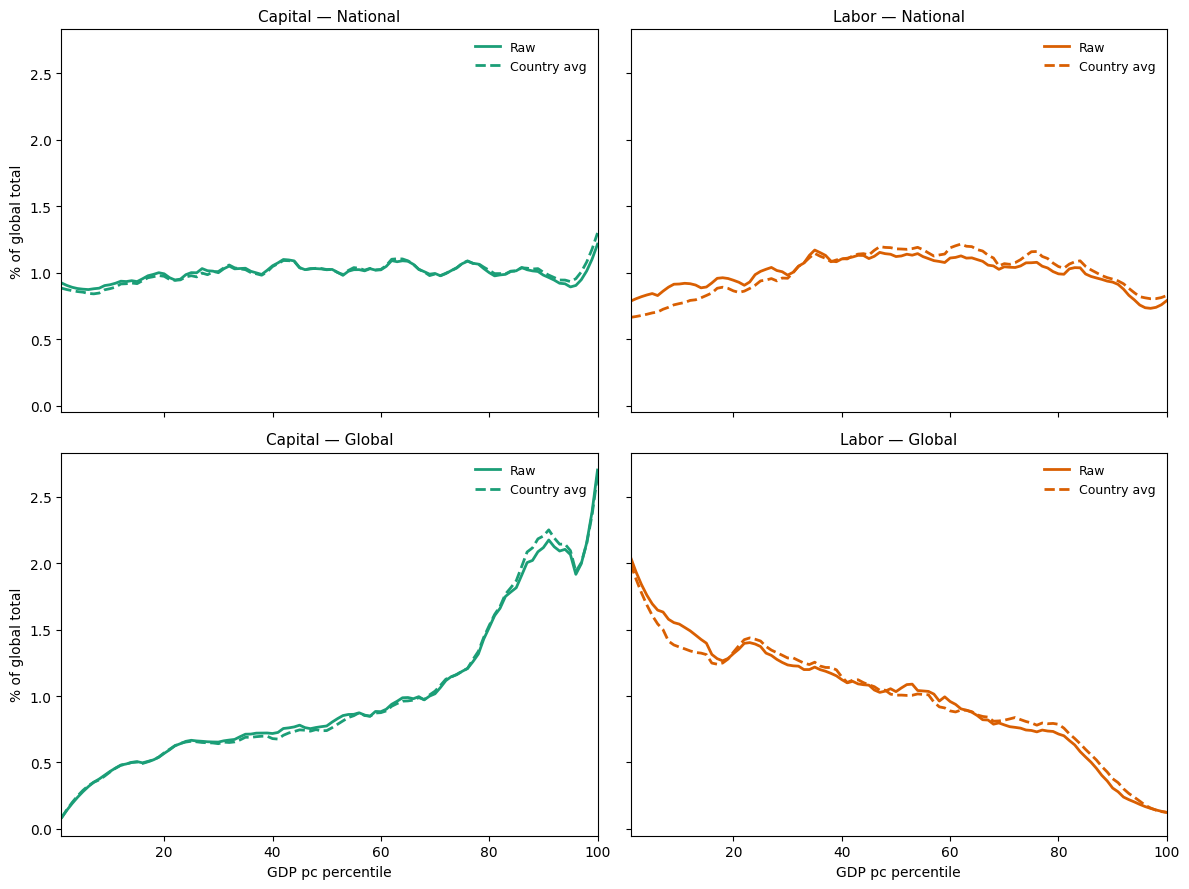

In [24]:
### --- Chart 1: 2x2 small multiples (rows = national/global, cols = capital/labor) ---

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)

panel_specs = [
    # (row, col, raw_series, avg_series, color, title)
    (0, 0, capital_pct_nat_s,  capital_avg_pct_nat_s,  "#1b9e77", "Capital — National"),
    (0, 1, labor_pct_nat_s,    labor_avg_pct_nat_s,    "#d95f02", "Labor — National"),
    (1, 0, capital_pct_glob_s, capital_avg_pct_glob_s, "#1b9e77", "Capital — Global"),
    (1, 1, labor_pct_glob_s,   labor_avg_pct_glob_s,   "#d95f02", "Labor — Global"),
]

for row, col, raw_s, avg_s, color, title in panel_specs:
    ax = axes[row, col]
    ax.plot(raw_s.index, raw_s.values, label="Raw", color=color, linewidth=2)
    ax.plot(avg_s.index, avg_s.values, label="Country avg", color=color, linewidth=2, linestyle="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlim(1, 100)
    ax.legend(frameon=False, fontsize=9)

for ax in axes[1, :]:
    ax.set_xlabel("GDP pc percentile")
for ax in axes[:, 0]:
    ax.set_ylabel("% of global total")

plt.tight_layout()
plt.savefig(f"{fd}/capital_labor_small_multiples.png", dpi=300, bbox_inches="tight")
plt.show()

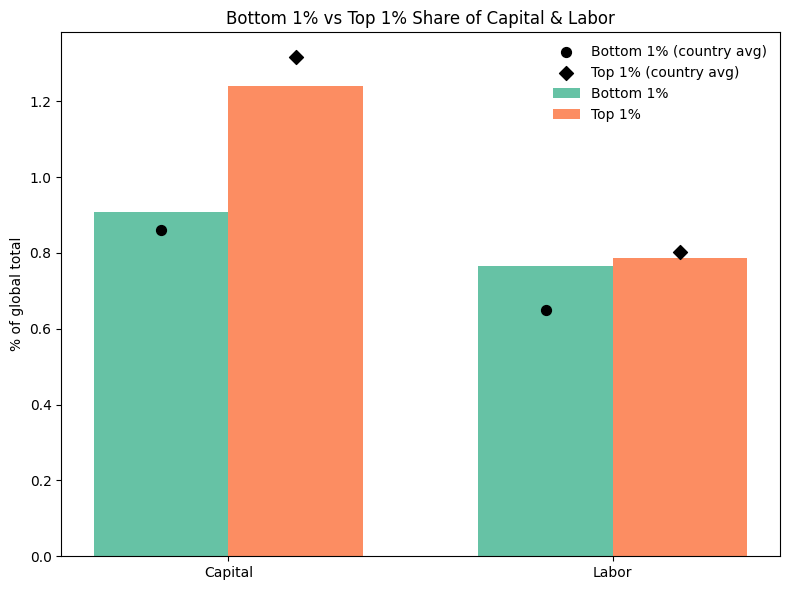

In [14]:
### --- Bottom X% vs Top X% bar chart (X settable), with country avg as overlaid dots ---

def bottom_top_share(pct_series, X):
    """Return (bottom X%, top X%) share of total, given a 1-100 percentile % series."""
    bottom = pct_series.loc[1:X].sum()
    top    = pct_series.loc[101-X:100].sum()
    return bottom, top

def plot_bottom_top(X, save_name="bottom_top_share.png"):
    cap_bot, cap_top         = bottom_top_share(capital_pct, X)
    cap_avg_bot, cap_avg_top = bottom_top_share(capital_avg_pct, X)
    lab_bot, lab_top         = bottom_top_share(labor_pct, X)
    lab_avg_bot, lab_avg_top = bottom_top_share(labor_avg_pct, X)

    groups = ["Capital", "Labor"]
    bottoms     = [cap_bot, lab_bot]
    tops        = [cap_top, lab_top]
    bottoms_avg = [cap_avg_bot, lab_avg_bot]
    tops_avg    = [cap_avg_top, lab_avg_top]

    x = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(x - width/2, bottoms, width, label=f"Bottom {X}%", color="#66c2a5")
    ax.bar(x + width/2, tops,    width, label=f"Top {X}%",    color="#fc8d62")

    # Overlay country-avg values as dots on top of each bar
    ax.scatter(x - width/2, bottoms_avg, color="black", zorder=3, s=50,
               label=f"Bottom {X}% (country avg)", marker="o")
    ax.scatter(x + width/2, tops_avg, color="black", zorder=3, s=50,
               label=f"Top {X}% (country avg)", marker="D")

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylabel("% of global total")
    ax.set_title(f"Bottom {X}% vs Top {X}% Share of Capital & Labor")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(f"{fd}/{save_name}", dpi=300, bbox_inches="tight")
    plt.show()

# Example usage — set X here:
plot_bottom_top(X=1, save_name="bottom_top10_share.png")